**Table of contents**<a id='toc0_'></a>    
- [OpenCV Image Processing Study Guide](#toc1_)    
  - [Setup - loading image](#toc1_1_)    
  - [`13.Grayscale processing.pdf`](#toc1_2_)    
  - [`14.Binary image.pdf`](#toc1_3_)    
  - [`15.Edge green detection.pdf`](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->


# <a id='toc1_'></a>[OpenCV Image Processing Study Guide](#toc0_)

A practical walkthrough of grayscale conversion, binary thresholding, and edge detection using the PDFs in this folder.


## <a id='toc1_1_'></a>[Setup - loading image](#toc0_)

Bring in OpenCV / NumPy / matplotlib, locate a demo image, and decode it into a BGR `ndarray`.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Search a few common locations for a demo image.
def find_image(name: str) -> Path:
    for root in (Path("."), Path(".."), Path("../.."), Path("../../..")):
        p = (root / name)
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(f"Could not find {name}")

img_path = find_image("render1.jpg")
img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
if img is None:
    raise RuntimeError(f"Failed to read {img_path}")

h, w = img.shape[:2]
print(f"loaded: {img_path.name}   shape={img.shape}   dtype={img.dtype}   {w}x{h}")


loaded: render1.jpg   shape=(4032, 2268, 3)   dtype=uint8   2268x4032


## <a id='toc1_2_'></a>[`13.Grayscale processing.pdf`](#toc0_)



What it covers:

- Converting a color (BGR) image to grayscale.

- Several algorithms: max, average, weighted average (`gray = 0.299·R + 0.587·G + 0.114·B`), and OpenCV's built-in.

- Why grayscale: lower memory, faster downstream processing, single-channel input for thresholding/edges.





### Converting a color (BGR) image to grayscale

A grayscale image stores one intensity value per pixel instead of three color channels. This is the standard way to simplify a color image before applying many classic image-processing steps.





### Comparing common grayscale algorithms

The examples below contrast the max, average, weighted-average, and OpenCV built-in conversions so you can see how different formulas change brightness, contrast, and perceived detail.





### Why grayscale is a useful preprocessing step

Single-channel images use less memory, run faster through later operations, and match the input format expected by many thresholding and edge-detection algorithms.



Core APIs:

- `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)` — built-in weighted conversion.

- `cv2.imread(path, 0)` — load directly as grayscale.

- NumPy mean / max for the manual variants.



img            shape: (4032, 2268, 3)            dtype: uint8
gray_cv        shape: (4032, 2268)             dtype: uint8
gray_max       shape: (4032, 2268)             dtype: uint8
gray_avg       shape: (4032, 2268)             dtype: uint8
gray_weighted  shape: (4032, 2268)             dtype: uint8


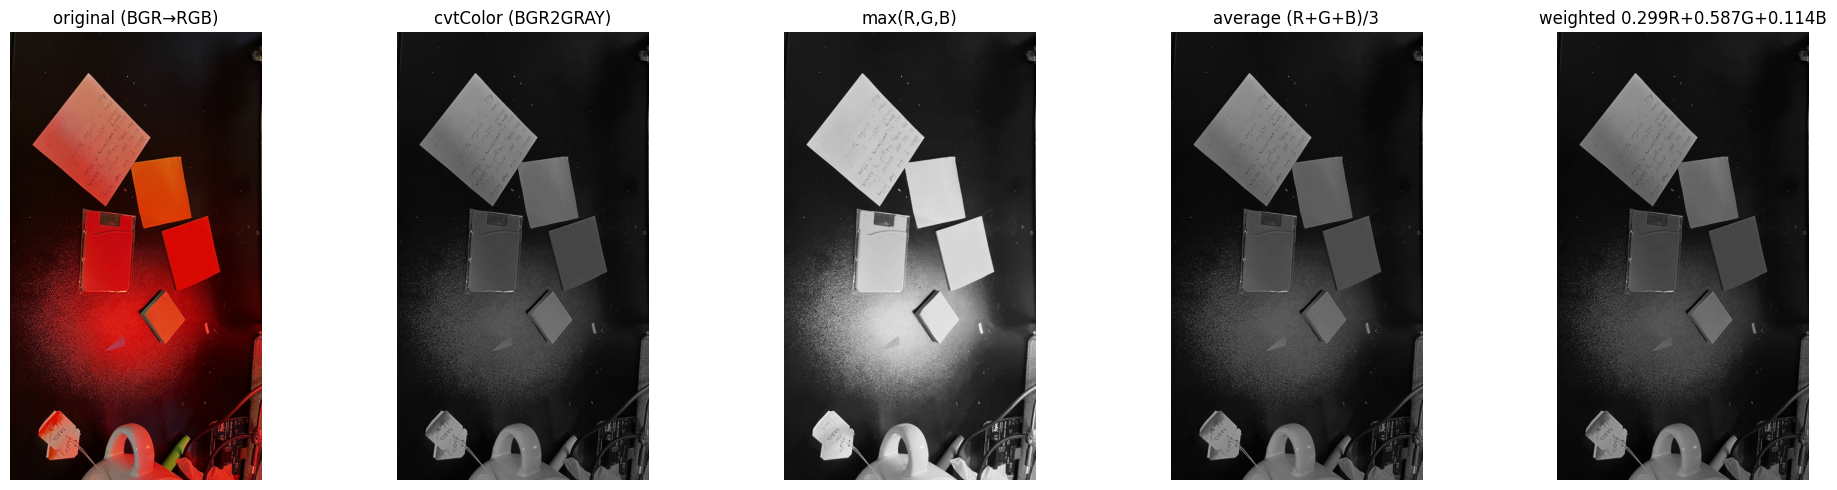

In [2]:
# 13.Grayscale processing.pdf -----------------------------------------------
# Four ways to produce a grayscale version of `img`.
# (1) cvtColor — OpenCV's standard ITU-R BT.601 weighted average (Y).
gray_cv = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# (2) Maximum method: gray = max(R, G, B). Tends to look bright.
gray_max = img.max(axis=2).astype(np.uint8)

# (3) Average method: gray = (R + G + B) / 3. Softer than the max method.
gray_avg = img.mean(axis=2).astype(np.uint8)

# (4) Weighted average: gray = 0.299·R + 0.587·G + 0.114·B (manual).
b, g, r = cv2.split(img)
gray_weighted = (0.299 * r + 0.587 * g + 0.114 * b).astype(np.uint8)

print(f"img            shape: {img.shape}            dtype: {img.dtype}")
print(f"gray_cv        shape: {gray_cv.shape}             dtype: {gray_cv.dtype}")
print(f"gray_max       shape: {gray_max.shape}             dtype: {gray_max.dtype}")
print(f"gray_avg       shape: {gray_avg.shape}             dtype: {gray_avg.dtype}")
print(f"gray_weighted  shape: {gray_weighted.shape}             dtype: {gray_weighted.dtype}")

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
panels = [
    (cv2.cvtColor(img, cv2.COLOR_BGR2RGB), "original (BGR→RGB)", None),
    (gray_cv,       "cvtColor (BGR2GRAY)",         "gray"),
    (gray_max,      "max(R,G,B)",                   "gray"),
    (gray_avg,      "average (R+G+B)/3",            "gray"),
    (gray_weighted, "weighted 0.299R+0.587G+0.114B","gray"),
]
for ax, (im, title, cmap) in zip(axes, panels):
    ax.imshow(im, cmap=cmap, vmin=0 if cmap else None, vmax=255 if cmap else None)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## <a id='toc1_3_'></a>[`14.Binary image.pdf`](#toc0_)



What it covers:

- Picking a threshold T and mapping every pixel to 0 or `maxValue` (typically 255).

- Five global thresholding modes in `cv2.threshold`: `BINARY`, `BINARY_INV`, `TRUNC`, `TOZERO`, `TOZERO_INV`.

- Otsu's method (`cv2.THRESH_OTSU`) — automatically picks T from the histogram.

- Adaptive thresholding (`cv2.adaptiveThreshold`) — local T per neighborhood for uneven lighting.





### Picking a global threshold T

A global threshold uses one cutoff value for the whole image. Pixels are compared against that value and then remapped according to the threshold mode you choose.





### Understanding the five thresholding modes

`BINARY` and `BINARY_INV` create black-and-white masks, while `TRUNC`, `TOZERO`, and `TOZERO_INV` keep selected portions of the original grayscale intensities instead of forcing everything to 0 or 255.





### Letting Otsu's method choose T automatically

Otsu's method analyzes the grayscale histogram and picks a threshold that best separates two intensity groups. It is useful when the image naturally splits into darker and lighter regions.





### Using adaptive thresholding for uneven lighting

Adaptive thresholding computes a different cutoff in each local neighborhood, which makes it much more reliable when shadows, glare, or gradients make one global threshold fail.



Core APIs:

- `cv2.threshold(src, thresh, maxValue, type)` → returns `(used_T, dst)`.

- `cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, type, blockSize, C)`.



manual T       : 127
Otsu T (auto)  : 60.0


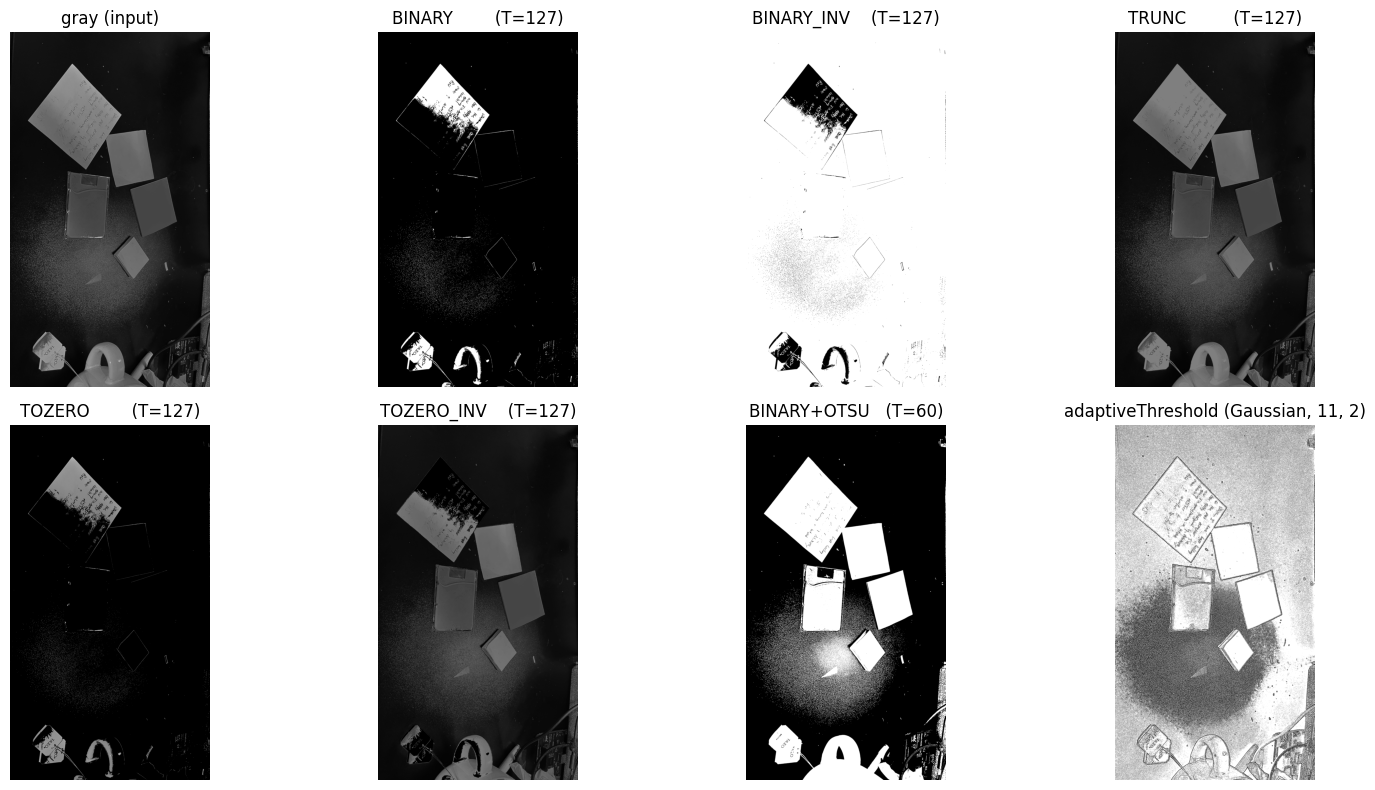

In [3]:
# 14.Binary image.pdf -------------------------------------------------------
# All thresholding requires a single-channel input — start from grayscale.
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

T = 127  # global threshold
_, th_binary     = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)
_, th_binary_inv = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY_INV)
_, th_trunc      = cv2.threshold(gray, T, 255, cv2.THRESH_TRUNC)
_, th_tozero     = cv2.threshold(gray, T, 255, cv2.THRESH_TOZERO)
_, th_tozero_inv = cv2.threshold(gray, T, 255, cv2.THRESH_TOZERO_INV)

# Otsu picks T automatically (passing 0 as `thresh` just tells OpenCV to ignore it).
T_otsu, th_otsu  = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptive thresholding handles uneven lighting by computing a local T per pixel.
th_adapt = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2,
)

print(f"manual T       : {T}")
print(f"Otsu T (auto)  : {T_otsu}")

panels = [
    (gray,           f"gray (input)"),
    (th_binary,      f"BINARY        (T={T})"),
    (th_binary_inv,  f"BINARY_INV    (T={T})"),
    (th_trunc,       f"TRUNC         (T={T})"),
    (th_tozero,      f"TOZERO        (T={T})"),
    (th_tozero_inv,  f"TOZERO_INV    (T={T})"),
    (th_otsu,        f"BINARY+OTSU   (T={T_otsu:.0f})"),
    (th_adapt,       f"adaptiveThreshold (Gaussian, 11, 2)"),
]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (im, title) in zip(axes.flat, panels):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## <a id='toc1_4_'></a>[`15.Edge green detection.pdf`](#toc0_)



What it covers:

- Reducing an image to its structural edges while discarding most pixel data.

- The 5-step **Canny** algorithm: Gaussian blur → gradient magnitude/direction → non-max suppression → double threshold → hysteresis.

- The **Sobel** operator: gradient approximation via a pair of 3×3 convolutions (x and y), combined as `√(Gx² + Gy²)`.

- A complementary green-region mask in HSV (the "green detection" twist) — useful for scoping edges to a colored object.





### Reducing an image to structural edges

Edge detection keeps the strongest intensity transitions and discards most flat regions. That makes object boundaries and overall shape much easier to inspect than the full color image.





### Understanding the Canny pipeline

Canny first smooths noise, then measures gradients, removes non-maximum responses, and finally keeps connected strong edges through double-threshold hysteresis. The result is usually a clean, thin edge map.





### Approximating gradients with the Sobel operator

Sobel computes horizontal and vertical derivatives with small convolution kernels. Combining those responses produces a gradient-magnitude image that highlights where intensity changes most strongly.





### Restricting edge analysis to green regions

HSV thresholding isolates pixels whose hue falls in the green range. Combining that mask with an edge image lets you keep only the contours that belong to a selected green object.



Core APIs:

- `cv2.GaussianBlur`, `cv2.Canny(img, threshold1, threshold2)`.

- `cv2.Sobel(src, ddepth, dx, dy, ksize)` + `cv2.magnitude` / `cv2.convertScaleAbs`.

- `cv2.cvtColor(..., COLOR_BGR2HSV)` + `cv2.inRange` for the green mask.



gray   shape/dtype: (4032, 2268) / uint8
canny  nonzero px :   480825  (Canny 50/150)
sobel  range      : 0..255
green  mask px    :     7401
green  edge px    :        8


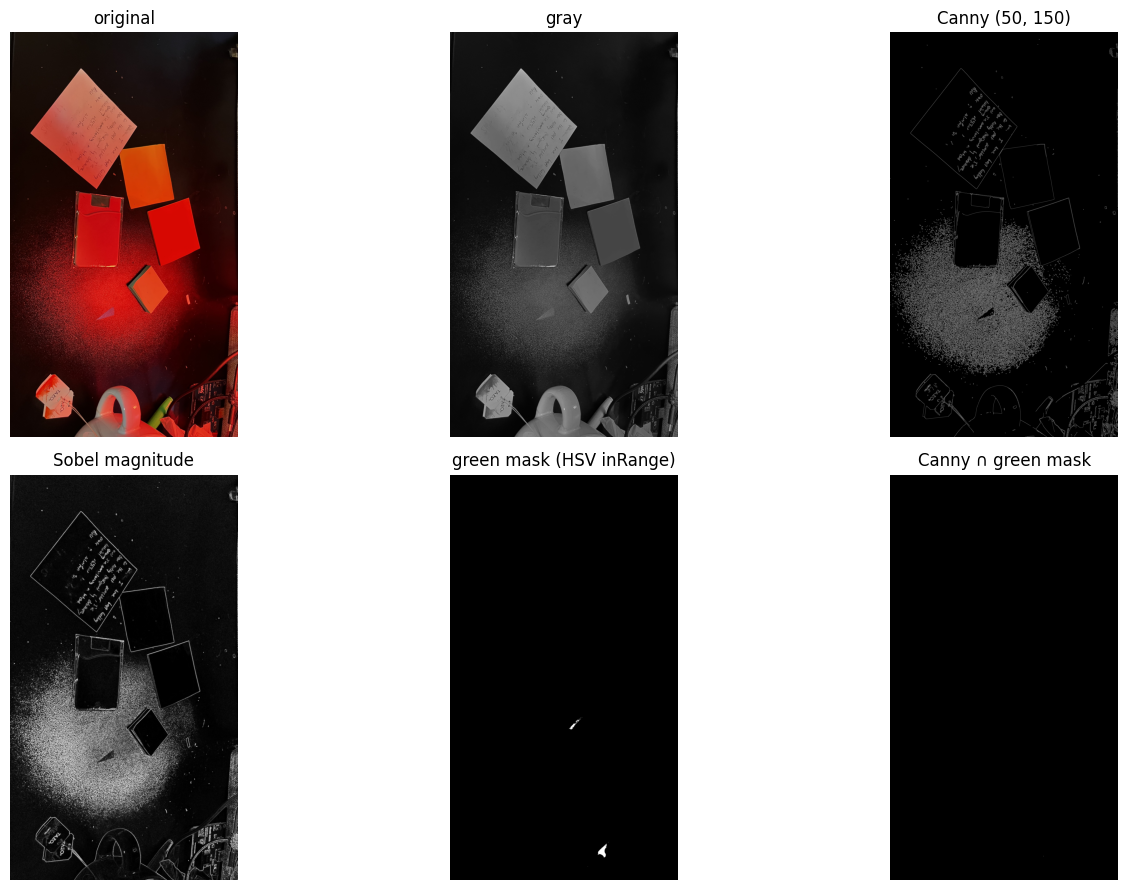

In [4]:
# 15.Edge green detection.pdf -----------------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Canny edges ----------------------------------------------------------
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
canny   = cv2.Canny(blurred, 50, 150)  # (low_thresh, high_thresh) for hysteresis

# --- Sobel edges ----------------------------------------------------------
gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)  # ∂I/∂x
gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)  # ∂I/∂y
mag = cv2.magnitude(gx, gy)                       # √(gx² + gy²)
sobel = np.clip(mag, 0, 255).astype(np.uint8)

# --- Green-region mask (HSV) ---------------------------------------------
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# Hue ~35-85 is the green band in OpenCV's 0-179 hue range.
green_mask = cv2.inRange(hsv, (35, 40, 40), (85, 255, 255))

# --- Edges restricted to the green region --------------------------------
green_edges = cv2.bitwise_and(canny, canny, mask=green_mask)

print(f"gray   shape/dtype: {gray.shape} / {gray.dtype}")
print(f"canny  nonzero px : {int((canny > 0).sum()):>8}  (Canny 50/150)")
print(f"sobel  range      : {sobel.min()}..{sobel.max()}")
print(f"green  mask px    : {int((green_mask > 0).sum()):>8}")
print(f"green  edge px    : {int((green_edges > 0).sum()):>8}")

panels = [
    (cv2.cvtColor(img, cv2.COLOR_BGR2RGB), "original",                 None),
    (gray,        "gray",                                              "gray"),
    (canny,       "Canny (50, 150)",                                   "gray"),
    (sobel,       "Sobel magnitude",                                   "gray"),
    (green_mask,  "green mask (HSV inRange)",                          "gray"),
    (green_edges, "Canny ∩ green mask",                                "gray"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (im, title, cmap) in zip(axes.flat, panels):
    ax.imshow(im, cmap=cmap, vmin=0 if cmap else None, vmax=255 if cmap else None)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()
